In [1]:
import importlib.util, sys, os

datasets_dir = "/beegfs/muduchuru/codes/physicsnemo/examples/weather/corrdiff/datasets"

# Create a package module object for 'datasets'
spec_pkg = importlib.util.spec_from_loader("datasets", loader=None)
pkg = importlib.util.module_from_spec(spec_pkg)
pkg.__path__ = [datasets_dir]
sys.modules["datasets"] = pkg

# Now load the submodule as 'datasets.mswx_dwd'
spec = importlib.util.spec_from_file_location("datasets.mswxdwd",
                                              os.path.join(datasets_dir, "mswxdwd.py"))
mod = importlib.util.module_from_spec(spec)
sys.modules[spec.name] = mod
spec.loader.exec_module(mod)

print(mod.mswxdwd)  # class is available

<class 'datasets.mswxdwd.mswxdwd'>


In [2]:
dataloader = mod.mswxdwd(
    data_path='/beegfs/muduchuru/data',
    input_channels = ['pr','tas'],
    output_channels = ['pr','tas'],
    static_channels = ['elevation', 'lsm', 'dwd_mask','pos_embed'],
    stats_dwd = '/beegfs/muduchuru/data/hyras_daily/hyras_stats.json',
    stats_mswx = '/beegfs/muduchuru/data/mswx/mswx_stats.json',
    )

Creating regridded elevation file using CDO: gmted_dwd_cropped_bilinear.nc
cdo    remapbil: Bilinear weights from lonlat (86400x33600) to curvilinear (642x867) grid
Regridded elevation file created: gmted_dwd_cropped_bilinear.nc


/home/muduchuru/miniforge3/envs/diffusion/lib/python3.10/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')


In [3]:
dataloader.input_channels()

[ChannelMetadata(name='pr', level='', auxiliary=False),
 ChannelMetadata(name='tas', level='', auxiliary=False),
 ChannelMetadata(name='elevation', level='', auxiliary=False),
 ChannelMetadata(name='lsm', level='', auxiliary=False),
 ChannelMetadata(name='dwd_mask', level='', auxiliary=False),
 ChannelMetadata(name='pos_embed_lat', level='', auxiliary=False),
 ChannelMetadata(name='pos_embed_lon', level='', auxiliary=False)]

In [4]:
import numpy as np
from datetime import datetime
t = datetime.strptime('1989-01-01', '%Y-%m-%d')
data = dataloader._get_dwd(t)
mask1 = np.where(np.isnan(data[0]), 0.0, 1.0).astype(np.float32)
mask2 = np.where(np.isnan(data[1]), 0.0, 1.0).astype(np.float32)
same_mask = np.array_equal(mask1, mask2)
print("Are masks identical?", same_mask)

Are masks identical? True


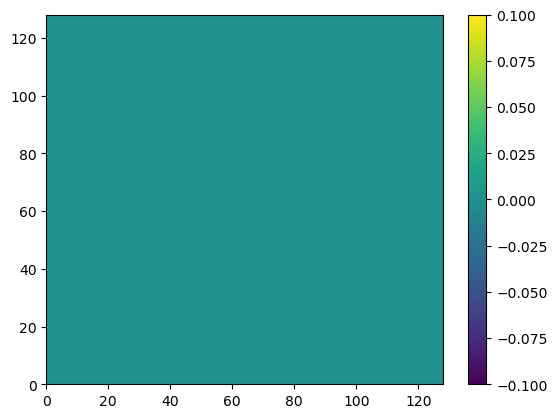

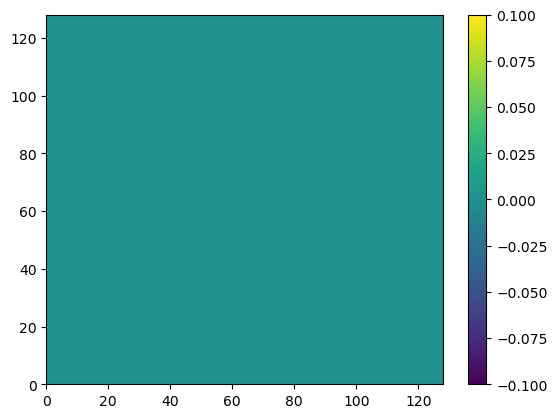

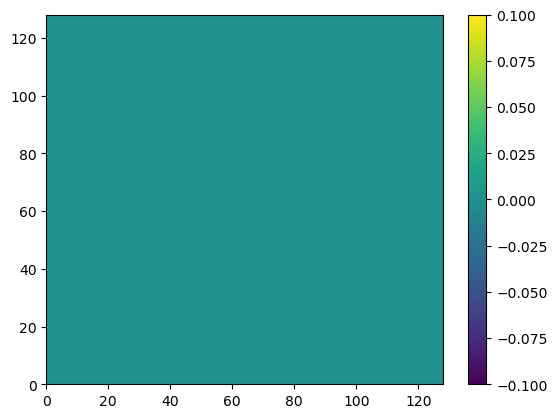

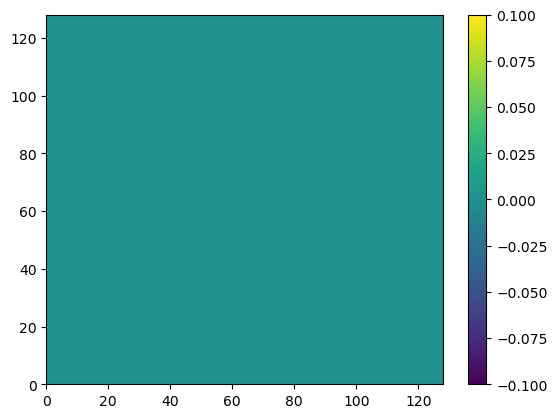

In [10]:
import matplotlib.pyplot as plt
data = dataloader[200]
plt.figure()
plt.pcolormesh(data[1][0])
plt.colorbar()
plt.figure()
plt.pcolormesh(data[1][1])
plt.colorbar()

plt.figure()
plt.pcolormesh(data[0][0])
plt.colorbar()
plt.figure()
plt.pcolormesh(data[0][1])
plt.colorbar()


In [13]:
data[1].shape

torch.Size([7, 128, 128])

In [15]:
import importlib.util, sys, os

datasets_dir = "/beegfs/muduchuru/codes/physicsnemo/examples/weather/corrdiff/datasets"

# Create a package module object for 'datasets'
spec_pkg = importlib.util.spec_from_loader("datasets", loader=None)
pkg = importlib.util.module_from_spec(spec_pkg)
pkg.__path__ = [datasets_dir]
sys.modules["datasets"] = pkg

# Now load the submodule as 'datasets.mswx_dwd'
spec = importlib.util.spec_from_file_location("datasets.era5_mswx",
                                              os.path.join(datasets_dir, "era5_mswx.py"))
mod = importlib.util.module_from_spec(spec)
sys.modules[spec.name] = mod
spec.loader.exec_module(mod)

print(mod.era5_mswx)  # class is available

<class 'datasets.era5_mswx.era5_mswx'>


In [18]:
dataloader = mod.era5_mswx(
    data_path='/beegfs/muduchuru/data',
    input_channels = ['pr','tas'],
    output_channels = ['pr','tas'],
    static_channels = ['elevation', 'lsm'],
    stats_era5 = '/beegfs/muduchuru/data/era5/europe_stats.json',
    stats_mswx = '/beegfs/muduchuru/data/mswx/mswx_stats.json',
    )
data = dataloader[200]

In [22]:
dataloader.input_channels()

[ChannelMetadata(name='pr', level='', auxiliary=False),
 ChannelMetadata(name='tas', level='', auxiliary=False),
 ChannelMetadata(name='elevation', level='', auxiliary=False),
 ChannelMetadata(name='lsm', level='', auxiliary=False)]